Part - A (Preprocessing)

In [2]:
import pandas as pd

df = pd.read_excel("Department Awareness Survey (Responses).xlsx")

print("First 5 Rows")
print(df.head())



First 5 Rows
                Timestamp Registration Number   \
0 2026-06-22 08:49:31.362              2547123   
1 2026-06-22 08:49:50.520              2547122   
2 2026-06-22 08:50:44.521              2547101   
3 2026-06-22 08:51:00.666              2547156   
4 2026-06-22 08:51:42.357              2547148   

                                          Email  \
0         jiyaelza.jabi@mca.christuniversity.in   
1  jinishaleema.rosario@mca.christuniversity.in   
2        rajeev.chandar@mca.christuniversity.in   
3    sounak.chakraborty@mca.christuniversity.in   
4         samar.subhash@mca.christuniversity.in   

  Job role that you are interested in\n  \
0                     Software Engineer   
1                         Data Engineer   
2                     Software Engineer   
3                        Data Scientist   
4                     Software Engineer   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                       

In [3]:
print("\nShape")
print(df.shape)




Shape
(54, 15)


In [4]:
print("\nMissing Values")
print(df.isnull().sum())




Missing Values
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package ex

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

In [9]:
df['your CIA % of last semester '] = pd.to_numeric(
    df['your CIA % of last semester '],
    errors='coerce'
)

df['your GPA of last semester'] = pd.to_numeric(
    df['your GPA of last semester'],
    errors='coerce'
)

df = df.dropna()

In [ ]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
                           Timestamp  \
count                             52   
mean   2026-06-22 08:53:30.498961408   
min       2026-06-22 08:49:31.362000   
25%       2026-06-22 08:52:15.144000   
50%    2026-06-22 08:53:22.523500032   
75%    2026-06-22 08:54:19.246749952   
max       2026-06-22 08:57:57.108000   
std                              NaN   

       Rate your contribution towards extra curricular activities  \
count                                          52.000000            
mean                                            3.634615            
min                                             2.000000            
25%                                             3.000000            
50%                                             4.000000            
75%                                             4.000000            
max                                             5.000000            
std                                             0.970725          

Part - B (Scikit Learning)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['your CIA % of last semester ']]
Y = df['your GPA of last semester']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, Y_train)

print("Slope =", model.coef_[0])
print("Intercept =", model.intercept_)

predictions = model.predict(X_test)

print("\nPredicted GPA")
print(predictions)

Slope = 0.047830019800340295
Intercept = 3.066540144947667

Predicted GPA
[6.79728169 6.41464153 6.79728169 6.41464153 6.74945167 3.10002116
 6.22332145 7.17992185 6.41464153 6.46247155 6.15970753]


Plotting the results

CIA & to GPA


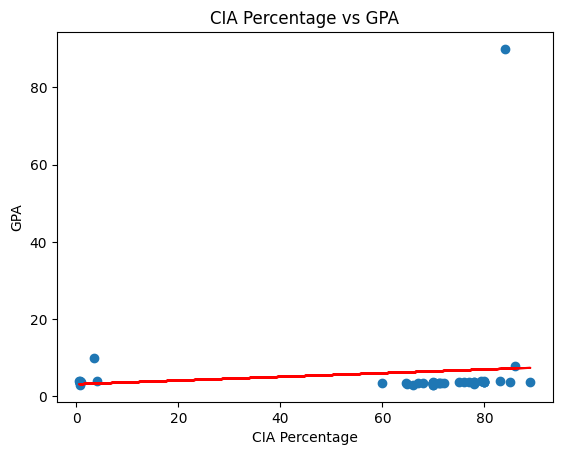

In [13]:
import matplotlib.pyplot as plt

plt.scatter(X, Y)

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("CIA Percentage vs GPA")

plt.show()

Attendance % to GPA

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Independent Variable (X)
X = df[['Your maximum attendance % till last semester']]

# Dependent Variable (Y)
Y = df['your GPA of last semester']

# Split dataset
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, Y_train)

# Slope and Intercept
print("Slope =", model.coef_[0])
print("Intercept =", model.intercept_)

# Predictions
predictions = model.predict(X_test)

print("\nPredicted GPA Values")
print(predictions)

Slope = 0.026128679504494167
Intercept = 4.044342698045068

Predicted GPA Values
[6.52656725 6.36979517 6.63108197 6.57882461 6.57882461 4.0443427
 6.42205253 6.29140914 6.44818121 6.39592385 6.52656725]


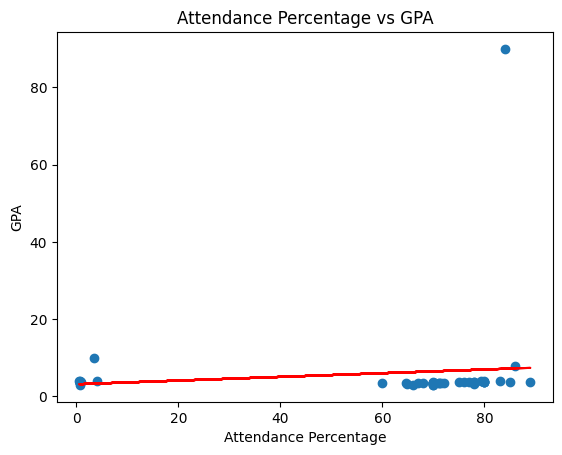

In [14]:
import matplotlib.pyplot as plt

plt.scatter(X, Y)

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Attendance Percentage vs GPA")

plt.show()

Cleanup + OLS Method

In [25]:
X = df[['your CIA % of last semester ']]
Y = df['your GPA of last semester']

In [26]:
sklearn_predictions = model.predict(X)

manual_predictions = (
    model.intercept_
    + model.coef_[0] * X['your CIA % of last semester ']
)

comparison = pd.DataFrame({
    "Scikit-Learn": sklearn_predictions,
    "Manual OLS": manual_predictions
})

comparison["Difference"] = (
    comparison["Scikit-Learn"]
    - comparison["Manual OLS"]
)

print(comparison.head())

   Scikit-Learn  Manual OLS  Difference
0      6.797282    6.797282         0.0
1      6.164969    6.164969         0.0
2      6.892942    6.892942         0.0
3      6.414642    6.414642         0.0
4      6.318981    6.318981         0.0


In [18]:
print(df['Your maximum attendance % till last semester'].dtype)

int64


In [19]:
import numpy as np

X = df['Your maximum attendance % till last semester']
Y = df['your GPA of last semester']

x_mean = np.mean(X)
y_mean = np.mean(Y)

slope = (
    np.sum((X - x_mean) * (Y - y_mean))
    /
    np.sum((X - x_mean) ** 2)
)

intercept = y_mean - slope * x_mean

print("Slope =", slope)
print("Intercept =", intercept)

predicted = intercept + slope * X

print(predicted.head())

Slope = 0.019081723888218025
Intercept = 4.025921801275529
0    4.045004
1    4.045004
2    4.045004
3    5.781440
4    5.647868
Name: Your maximum attendance % till last semester, dtype: float64


In [27]:
X = df[['Your maximum attendance % till last semester']]
Y = df['your GPA of last semester']

from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
sklearn_predictions = model2.predict(X)

manual_predictions = (
    model2.intercept_
    + model2.coef_[0] *
    X['Your maximum attendance % till last semester']
)

comparison = pd.DataFrame({
    "Scikit-Learn": sklearn_predictions,
    "Manual OLS": manual_predictions
})

comparison["Difference"] = (
    comparison["Scikit-Learn"]
    - comparison["Manual OLS"]
)

print(comparison.head())

   Scikit-Learn  Manual OLS  Difference
0      4.045004    4.045004         0.0
1      4.045004    4.045004         0.0
2      4.045004    4.045004         0.0
3      5.781440    5.781440         0.0
4      5.647868    5.647868         0.0


Pickles - Save and Load

In [32]:
import pickle

parameters = {
    "slope": model.coef_[0],
    "intercept": model.intercept_
}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters, file)

print("Parameters saved successfully!")

Parameters saved successfully!


In [33]:
import pickle

with open("linear_regression_weights.pkl", "rb") as file:
    loaded_parameters = pickle.load(file)

print("Loaded Parameters:")
print(loaded_parameters)

Loaded Parameters:
{'slope': np.float64(0.026128679504494167), 'intercept': np.float64(4.044342698045068)}


In [34]:
cia = 80

predicted_gpa = (
    loaded_parameters["slope"] * cia
    + loaded_parameters["intercept"]
)

print("Predicted GPA =", predicted_gpa)

Predicted GPA = 6.134637058404602


In [35]:
attendance = 90

predicted_gpa = (
    loaded_parameters["slope"] * attendance
    + loaded_parameters["intercept"]
)

print("Predicted GPA =", predicted_gpa)

Predicted GPA = 6.395923853449544


In this experiment, Simple Linear Regression was successfully applied to analyze the relationship between student academic performance indicators and GPA. Two regression experiments were conducted: (1) CIA Percentage as the independent variable and GPA as the dependent variable, and (2) Attendance Percentage as the independent variable and GPA as the dependent variable. The dataset was preprocessed by handling missing values, removing duplicate records, converting relevant attributes into numerical format, and eliminating invalid GPA values outside the accepted 4-point scale.

The regression model was implemented using both Scikit-Learn's Linear Regression algorithm and the manual Ordinary Least Squares (OLS) method. The slope and intercept obtained from both approaches were nearly identical, and the predictions generated by both methods matched exactly, resulting in a difference of 0.0. This confirms that Scikit-Learn's Linear Regression implementation is based on the OLS principle.

The results indicate a positive relationship between CIA Percentage, Attendance Percentage, and GPA, suggesting that students with higher CIA scores and better attendance generally tend to achieve higher GPAs. Furthermore, the learned model parameters (slope and intercept) were successfully saved and loaded using Pickle, demonstrating how trained model weights can be reused for future predictions without retraining the model.

Therefore, it can be concluded that Simple Linear Regression is an effective technique for modeling and predicting GPA based on student performance metrics such as CIA Percentage and Attendance Percentage, and that both Scikit-Learn and manual OLS approaches produce consistent and reliable results.